# 1. Import Libraries

In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Load Dataset

In [42]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)
df = pd.read_csv(os.path.join(path, 'AB_NYC_2019.csv'))

Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
Path to dataset files: /kaggle/input/new-york-city-airbnb-open-data


In [43]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [45]:
df.describe(include='all')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48879,4.889500e+04,48874,48895,48895,48895.000000,48895.000000,48895,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
unique,NaN,47905,NaN,11452,5,221,NaN,NaN,3,NaN,NaN,NaN,1764,NaN,NaN,NaN
top,NaN,Hillside Hotel,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,NaN,18,NaN,417,21661,3920,NaN,NaN,25409,NaN,NaN,NaN,1413,NaN,NaN,NaN
mean,1.901714e+07,NaN,6.762001e+07,NaN,NaN,NaN,40.728949,-73.952170,NaN,152.720687,7.029962,23.274466,NaN,1.373221,7.143982,112.781327
std,1.098311e+07,NaN,7.861097e+07,NaN,NaN,NaN,0.054530,0.046157,NaN,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,0.000000,1.000000,0.000000,NaN,0.010000,1.000000,0.000000
25%,9.471945e+06,NaN,7.822033e+06,NaN,NaN,NaN,40.690100,-73.983070,NaN,69.000000,1.000000,1.000000,NaN,0.190000,1.000000,0.000000
50%,1.967728e+07,NaN,3.079382e+07,NaN,NaN,NaN,40.723070,-73.955680,NaN,106.000000,3.000000,5.000000,NaN,0.720000,1.000000,45.000000
75%,2.915218e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763115,-73.936275,NaN,175.000000,5.000000,24.000000,NaN,2.020000,2.000000,227.000000


In [46]:
df.shape

(48895, 16)

# 3. EDA

**3.1 Missing Value**

In [47]:
missing = df.isnull().sum()
missing[missing > 0]

,0
name,16
host_name,21
last_review,10052
reviews_per_month,10052


In [48]:
df['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

**3.2 Target variable - room_type**

<Axes: xlabel='room_type', ylabel='count'>

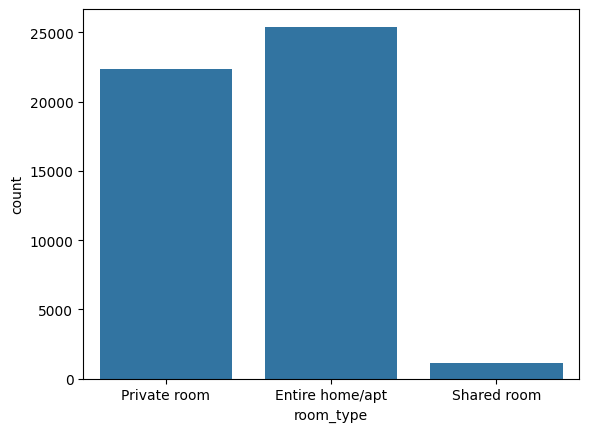

In [49]:
df['room_type'].value_counts()
sns.countplot(x='room_type',data=df)

The classes are imbalanced -> Shared room is a small minority

**3.3 Univariate Analysis - Numeric Features**

In [50]:
df.select_dtypes(include='number').columns.tolist()

['id',
 'host_id',
 'latitude',
 'longitude',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

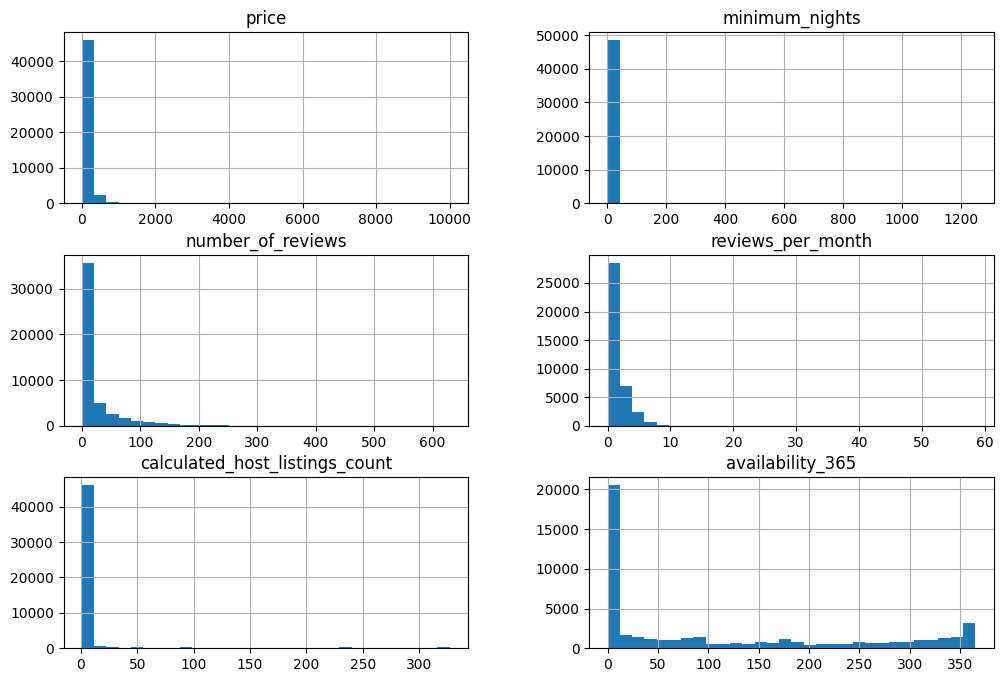

In [51]:
numerical_cols = ["price", "minimum_nights", "number_of_reviews",
                 "reviews_per_month", "calculated_host_listings_count",
                 "availability_365"]

df[numerical_cols].hist(bins=30, figsize=(12, 8))

**3.4 Univariate Analysis - Features vs Target**

<Axes: xlabel='neighbourhood_group', ylabel='count'>

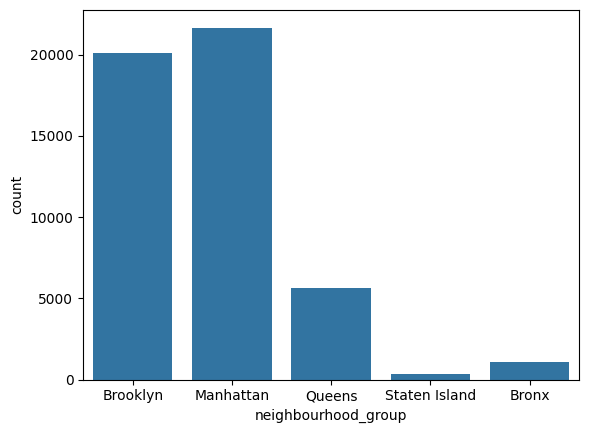

In [52]:
sns.countplot(data=df, x='neighbourhood_group')

**3.5 Bivariate Analysis**

<Axes: xlabel='room_type', ylabel='price'>

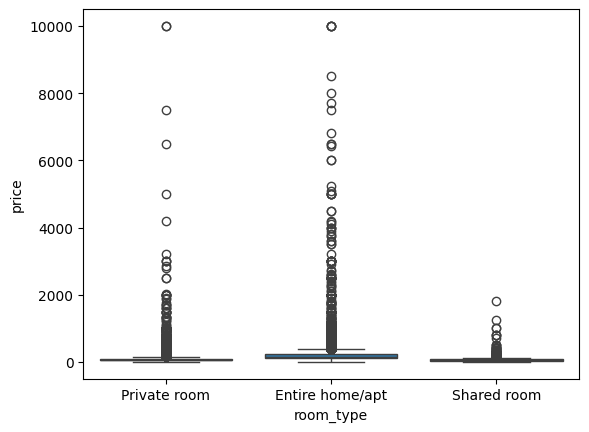

In [53]:
sns.boxplot(x ='room_type', y = 'price', data= df)

**3.6 Correlation Between Numeric Features**

<Axes: >

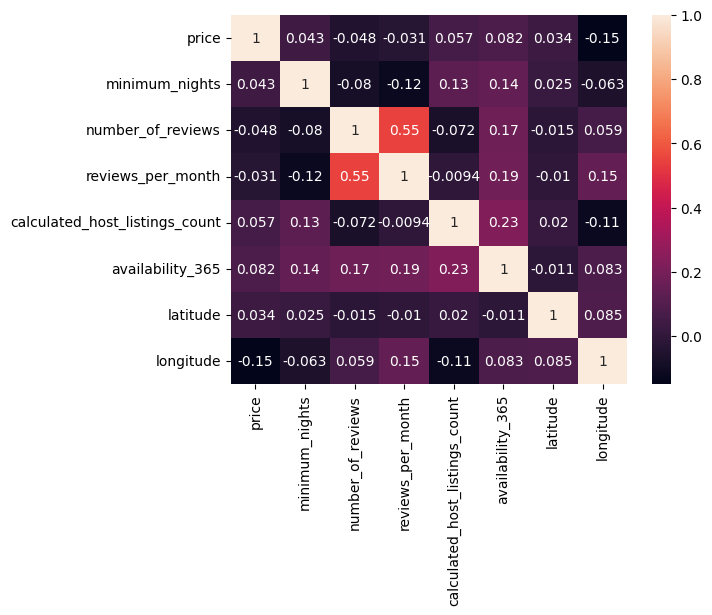

In [54]:
corr = df[numerical_cols + ['latitude', 'longitude']].corr()
sns.heatmap(corr,annot=True)


**3.7 Geographic Distribution (Bonus Visual)**

<Axes: xlabel='longitude', ylabel='latitude'>

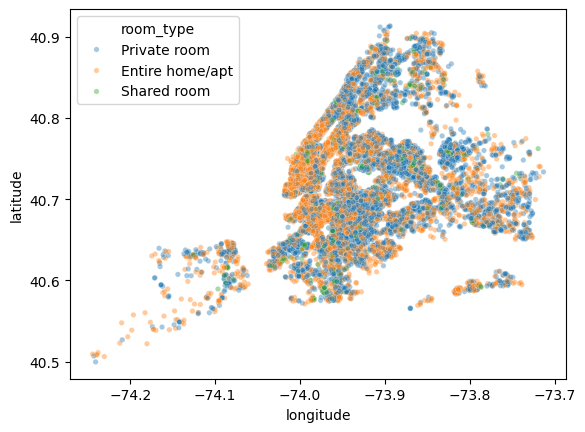

In [55]:
sns.scatterplot(data=df, x='longitude', y='latitude', hue='room_type', alpha=0.4, s=15)

# 4. Data Cleaning & Feature Engineering

In [56]:
# 1. Drop columns
df_clean = df.drop(columns=['id','name','host_name','last_review','host_id'])

#2. No reviews yet -> 0 reviews per month, not missing
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)



In [57]:
#3. Cap Extreme outliers instead of deleting rows.

price_cap  = df_clean['price'].quantile(0.99)
nights_cap = df_clean['minimum_nights'].quantile(0.99)

df_clean['price'] = df_clean['price'].clip(upper=price_cap)
df_clean['minimum_nights'] = df_clean['minimum_nights'].clip(upper=nights_cap)


# df_clean = df_clean[df_clean['price'] < price_cap]
# df_clean = df_clean[df_clean['minimum_nights'] < nights_cap]

In [58]:
x = df_clean.drop(columns=['room_type'])
y = df_clean['room_type']

# 5. Train / Test Split

We hold out 20% of the data as a test set that is never touched during model selection or tuning — it is only used once, at the very end, to report the final, honest performance. stratify=y keeps the same class proportions in both splits, which matters because the target is imbalanced.

In [59]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# 6. Preprocessing: ColumnTransformer + Pipeline

In [60]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer

In [61]:
numerical_cols = ["price", "minimum_nights", "number_of_reviews",
                 "reviews_per_month", "calculated_host_listings_count",
                 "availability_365"]
categorical_cols = ['neighbourhood_group','neighbourhood']

#1. Pipeline -> for Numeric Columns
numeric_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy="median")),
    ('skewness',SimpleImputer(strategy="median")),
    ('scale', StandardScaler())
])

#2. Pipeline -> for Categorical Columns
categorical_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy="most_frequent")),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ("numerical", numeric_pipeline, numerical_cols),
    ("categorical", categorical_pipeline, categorical_cols )
])

preprocessor

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('skewness',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['price', 'minimum_nights',
                                  'number_of_reviews', 'reviews_per_month',
                                  'calculated_host_listings_count',
                                  'availability_365']),
                                ('categorical',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encode',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['neighbourhood_group', 'neighbourhood'])])

In [62]:
df_clean['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

# 7. Trying Multiple Algorithms

**SMOTE (Synthetic Minority Oversampling).
for class IMbalance**

In [63]:
import warnings
warnings.filterwarnings('ignore')

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

In [65]:
# class_weight="Balanced" tells the model to pay more attention to the minority class
# or rare class (Shared Room)
# but the problem is GradintBossting doesnt support class weight so we left it as it is

In [66]:
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced',random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced',random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced',random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}
for name, model in models.items():
  pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])
  accuracy = cross_val_score(pipe, X_train, y_train,cv=3,scoring="accuracy")
  macrof1 = cross_val_score(pipe, X_train, y_train,cv=3,scoring="f1_macro")

  print(f"{name} -> Accuracy: {accuracy.mean():.3f} , F1: {macrof1.mean():.3f}")

Logistic Regression -> Accuracy: 0.661 , F1: 0.525
Decision Tree -> Accuracy: 0.782 , F1: 0.648
Random Forest -> Accuracy: 0.845 , F1: 0.708
Gradient Boosting -> Accuracy: 0.846 , F1: 0.697


In [67]:
# So we pick random forest

# 8. Hyperparameter Tuning

In [68]:
from sklearn.model_selection import RandomizedSearchCV

best_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   RandomForestClassifier(class_weight='balanced'))
])

param_distribution = {
    "classifier__n_estimators" : [100,200,150,300],
    "classifier__max_depth": [8, 12, 15, 20, None],
    "classifier__min_samples_split": [2, 5, 10],
}

search = RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_distribution,
    n_iter=10,
    cv=3,
    scoring="f1_macro",
    random_state=42
    )

search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numerical',
                                                                               Pipeline(steps=[('impute',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('skewness',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['price',
                                                                                'minimum_nights',
                                                                                'number_of_reviews',
                                                                                'reviews_per_month',
                                                                                'calculated_host_listings_count',
                                                                                'avai...
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encode',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['neighbourhood_group',
                                                                                'neighbourhood'])])),
                                             ('classifier',
                                              RandomForestClassifier(class_weight='balanced'))]),
                   param_distributions={'classifier__max_depth': [8, 12, 15, 20,
                                                                  None],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [100, 200,
                                                                     150,
                                                                     300]},
                   random_state=42, scoring='f1_macro')

In [69]:
print("Best Parameters: ", search.best_params_)
print("Best CV Macro-F1: ", search.best_score_)

Best Parameters:  {'classifier__n_estimators': 100, 'classifier__min_samples_split': 2, 'classifier__max_depth': 20}
Best CV Macro-F1:  0.7232354511640767


 # 9. Final Evaluation on the Test Set

In [70]:
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix
best_pipeline = search.best_estimator_
y_pred = best_pipeline.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test,y_pred)}")
print(f"F1 Score: {f1_score(y_test,y_pred,average='macro')}")

Accuracy Score: 0.8428264648737089
F1 Score: 0.7417872218916489


<Axes: >

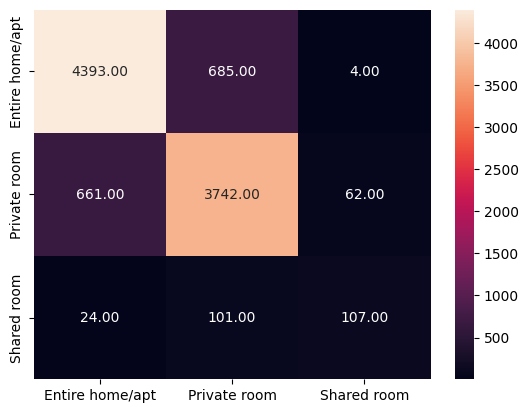

In [71]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt=".2f",
            xticklabels=best_pipeline.classes_, yticklabels=best_pipeline.classes_)

# 10. Saving the Final Model Artifact

In [72]:
import joblib
joblib.dump(best_pipeline, "Model_Pipeline.pkl",compress=3)

['Model_Pipeline.pkl']

In [73]:
df_clean.columns

Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')